# Healthcare Accessibility Index — Current State vs. AI Platform Scenario
### AI Regional Healthcare Coordination Platform · China (31 provincial units)

Recreation of the South Korea accessibility-index analysis for **mainland China's 31
provinces, autonomous regions and municipalities**. The notebook builds a 0–1 Healthcare
Accessibility Index from official statistics, projects the improvement under the proposed
AI coordination platform, and renders both as choropleth maps on a shared color scale.

China context: the country became an **aged society** (65+ share above 14%) in 2021 and
reached 15.4% by 2023; aging is deepest in the Northeast rust belt and the
Sichuan–Chongqing basin, while out-migration provinces face the same
"aging + regional decline + workforce shortage" triad as Korea's non-capital regions.
The platform's modules translate directly: AI triage aligned with China's 4-level ED
pre-triage standard (急诊预检分诊, Levels 1–4), capacity-aware routing across 医联体 /
county medical communities (县域医共体), and an interoperable EMR layer for the national
电子健康档案 push — with 120 dispatch integration in place of Korea's 119.

**Pipeline** (identical to the Korea notebook)

| Step | What happens | Method |
|---|---|---|
| 1 | Data assembly | 2 indicators per region, from official sources (referenced below) |
| 2 | Need adjustment | supply ÷ relative elderly burden |
| 3 | Normalization | min-max scaling → 0–1 index |
| 4 | Scenario projection | proportional gap-closure model (30%) |
| 5 | Map geometry | SVG province boundaries → matplotlib paths |
| 6 | Visualization | two choropleths, shared RdYlGn scale |
| 7 | Verification & export | ranking cross-check, sensitivity, CSV |

**Requirements**
```
pip install numpy pandas matplotlib svgpath2mpl
npm install @svg-maps/china        # map boundary geometry (MIT license)
```

## Step 1 — Data assembly (with references)

Two indicators per region:

| Column | Definition | Year | Source |
|---|---|---|---|
| `doctors_per_1k` | Licensed (assistant) physicians 执业（助理）医师 per 1,000 resident population | 2021 | China Health Statistics Yearbook 2022 (国家卫生健康委《中国卫生健康统计年鉴》, table 2-2-2), as reproduced in sector press: 赛柏蓝 via 健康界, Dec 17 2022, https://www.cn-healthcare.com/articlewm/20221217/content-1484954.html ; 罗志恒 (粤开证券) via 界面新闻, Apr 15 2022, https://www.jiemian.com/article/7337901.html |
| `pct_65plus` | Share of population aged 65+ (%) | 2020 | **7th National Population Census, Bulletin No. 5** (第七次全国人口普查公报（第五号）, Table 5-2), National Bureau of Statistics, https://www.stats.gov.cn/sj/zxfb/202302/t20230203_1901085.html |

**Data honesty — the `doc_est` flag.** Every `pct_65plus` value is exact from the census
bulletin. For `doctors_per_1k`, seven provinces are text-verified in the retrieved sources
(Beijing 5.1 — highest; Tianjin 3.8; Shanghai 3.4; Shandong 3.4 — rank 8; Henan 3.0 —
median; Guangdong 2.5 and Jiangxi 2.5 — the two lowest). The remaining 24 values
(`doc_est = True`) are transcribed to 0.1 precision from the same yearbook table as
commonly reproduced, constrained by the verified ranks and the sources' regional ordering
(top-10: Beijing/Tianjin/Hebei/Inner Mongolia + Shanghai/Zhejiang/Jiangsu/Shandong; bottom
group: Jiangxi/Guangdong/Yunnan/Anhui). Before publication, replace them with the exact
column from the yearbook itself (full PDF: National Health Commission,
https://www.nhc.gov.cn/mohwsbwstjxxzx/tjtjnj/ ). Step 7 shows the headline result is
robust to ±0.2 perturbations of every estimated value.

**Independent cross-check** (rank validation): 2023 national bulletin — physicians per
1,000 reached 3.40 nationally (2021: 3.04); Liaoning is China's oldest province at 21.1%
aged 65+ in 2023 vs. Guangdong among the youngest — same ordering as the 2020 census
shares used here (NHC 2023 Statistical Bulletin; 澎湃新闻, Nov 2024).

In [1]:
%matplotlib inline
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.colors import Normalize
from matplotlib import cm
from svgpath2mpl import parse_path

NATIONAL_AGED = 13.50  # national 65+ share (%), 2020 census — NBS Bulletin No. 5
GAP_CLOSURE   = 0.30   # Step 4 scenario assumption (platform closes 30% of each gap)

# key = region id used in the SVG boundary file (enables a join with no lookup table);
# note the package spells Qinghai as 'quinghai'.
DATA = {
    #  key                name             doc/1k  65+%   doc estimated?
    "beijing":         ("Beijing",         5.1,    13.30, False),
    "tianjin":         ("Tianjin",         3.8,    14.75, False),
    "hebei":           ("Hebei",           3.6,    13.92, True),
    "shanxi":          ("Shanxi",          3.2,    12.90, True),
    "nei-mongol":      ("Inner Mongolia",  3.6,    13.05, True),
    "liaoning":        ("Liaoning",        3.1,    17.42, True),
    "jilin":           ("Jilin",           3.3,    15.61, True),
    "heilongjiang":    ("Heilongjiang",    2.8,    15.61, True),
    "shanghai":        ("Shanghai",        3.4,    16.28, False),
    "jiangsu":         ("Jiangsu",         3.4,    16.20, True),
    "zhejiang":        ("Zhejiang",        3.7,    13.27, True),
    "anhui":           ("Anhui",           2.6,    15.01, True),
    "fujian":          ("Fujian",          2.8,    11.10, True),
    "jiangxi":         ("Jiangxi",         2.5,    11.89, False),
    "shandong":        ("Shandong",        3.4,    15.13, False),
    "henan":           ("Henan",           3.0,    13.49, False),
    "hubei":           ("Hubei",           3.0,    14.59, True),
    "hunan":           ("Hunan",           3.0,    14.81, True),
    "guangdong":       ("Guangdong",       2.5,    8.58,  False),
    "guangxi-zhuang":  ("Guangxi",         2.7,    12.20, True),
    "hainan":          ("Hainan",          2.8,    10.43, True),
    "chongqing":       ("Chongqing",       2.9,    17.08, True),
    "sichuan":         ("Sichuan",         2.9,    16.93, True),
    "guizhou":         ("Guizhou",         2.8,    11.56, True),
    "yunnan":          ("Yunnan",          2.6,    10.75, True),
    "xizang":          ("Tibet",           3.1,    5.67,  True),
    "shaanxi":         ("Shaanxi",         2.9,    13.32, True),
    "gansu":           ("Gansu",           2.7,    12.58, True),
    "quinghai":        ("Qinghai",         3.3,    8.68,  True),
    "ningxia-hui":     ("Ningxia",         3.3,    9.62,  True),
    "xinjiang-uygur":  ("Xinjiang",        3.2,    7.76,  True),
}

df = pd.DataFrame(
    [(k, *v) for k, v in DATA.items()],
    columns=["key", "region", "doctors_per_1k", "pct_65plus", "doc_est"],
).set_index("key")
df

,region,doctors_per_1k,pct_65plus,doc_est
key,,,,
beijing,Beijing,5.1,13.30,False
tianjin,Tianjin,3.8,14.75,False
hebei,Hebei,3.6,13.92,True
shanxi,Shanxi,3.2,12.90,True
nei-mongol,Inner Mongolia,3.6,13.05,True
liaoning,Liaoning,3.1,17.42,True
jilin,Jilin,3.3,15.61,True
heilongjiang,Heilongjiang,2.8,15.61,True
shanghai,Shanghai,3.4,16.28,False


## Step 2 — Need adjustment (the "per capita effect")

Raw physician density ignores *who* the population is: 1,000 residents of Chongqing
(17.1% elderly — China's oldest large region together with Liaoning and Sichuan) generate
far more care demand than 1,000 residents of Tibet (5.7% elderly, the youngest). Each
region's supply is therefore deflated by its **relative elderly burden**:

$$S_i = \frac{\text{doctors}_i}{\;\text{aged}_i / \text{aged}_{\text{national}}\;}$$

- A region with the national age structure keeps its raw density (denominator = 1).
- Chongqing: 2.9 → **2.29** effective supply (burden ratio 1.27).
- Tibet: 3.1 → **7.38** (burden ratio 0.42 — very young population, low per-capita need).

This is the simplest member of the *need-adjusted supply ratio* family used in
health-workforce research — transparent, and every input is citable.

**China-specific caveat:** per-capita physician distribution in China is comparatively
even, but distribution *per square kilometre* is extremely uneven (population-based Gini
≈ 0.0–0.1 vs. area-based ≈ 0.88 — Zhang et al., *Equity analysis of Chinese physician
allocation based on Gini coefficient and Theil index*, 2021, PMC8115393). The high
need-adjusted scores of young western regions (Tibet, Xinjiang, Qinghai) therefore
reflect **demographic** advantage only; their **geographic** access barriers are exactly
what Module B routing and Module D telemedicine target.

In [2]:
df["need_ratio"]  = df["pct_65plus"] / NATIONAL_AGED
df["need_adj_supply"] = df["doctors_per_1k"] / df["need_ratio"]
df.sort_values("need_adj_supply")[["region", "doctors_per_1k", "pct_65plus",
                                   "need_ratio", "need_adj_supply"]].round(3)

,region,doctors_per_1k,pct_65plus,need_ratio,need_adj_supply
key,,,,,
chongqing,Chongqing,2.9,17.08,1.265,2.292
sichuan,Sichuan,2.9,16.93,1.254,2.312
anhui,Anhui,2.6,15.01,1.112,2.338
liaoning,Liaoning,3.1,17.42,1.290,2.402
heilongjiang,Heilongjiang,2.8,15.61,1.156,2.422
hunan,Hunan,3.0,14.81,1.097,2.735
hubei,Hubei,3.0,14.59,1.081,2.776
shanghai,Shanghai,3.4,16.28,1.206,2.819
jiangsu,Jiangsu,3.4,16.20,1.200,2.833


## Step 3 — Normalization to the 0–1 index

Min-max scaling turns need-adjusted supply into the benchmark index:

$$\text{Index}_i = \frac{S_i - S_{\min}}{S_{\max} - S_{\min}}$$

Interpretation caveats:
- The index is **relative within mainland China, within this data vintage** — 0 = lowest
  need-adjusted supply among the 31 units, 1 = highest. It does **not** mean "no access."
- The headline pattern is the mirror image of the raw-density map: the **Northeast
  (Liaoning, Heilongjiang, Jilin) and the Chongqing–Sichuan basin** fall to the bottom
  once their heavy elderly burden is priced in, while young frontier regions rise —
  consistent with press analyses of China's "moderately aged" provinces (19 provinces
  past the 14% threshold by 2023, 澎湃新闻).

In [3]:
smin, smax = df["need_adj_supply"].min(), df["need_adj_supply"].max()
df["index_current"] = (df["need_adj_supply"] - smin) / (smax - smin)
df.sort_values("index_current", ascending=False)[["region", "index_current"]].round(2)

,region,index_current
key,,
xizang,Tibet,1.00
xinjiang-uygur,Xinjiang,0.64
beijing,Beijing,0.57
quinghai,Qinghai,0.56
ningxia-hui,Ningxia,0.46
guangdong,Guangdong,0.32
zhejiang,Zhejiang,0.29
nei-mongol,Inner Mongolia,0.28
hainan,Hainan,0.26


## Step 4 — Platform scenario projection

**Proportional gap-closure model:**

$$\text{Index}^{proj}_i = \text{Index}_i + \gamma\,(1 - \text{Index}_i), \qquad \gamma = 0.30$$

The platform adds no physicians; it raises *effective* accessibility through coordination —
**Module A** (AI triage on the 4-level 预检分诊 scale) removes non-urgent demand from
scarce tertiary-hospital capacity (China's 三级医院 absorb roughly half of all hospital
visits), **Module B** (capacity-aware routing) reallocates patients across 医联体 and
county medical communities, and **Module D** (telemedicine for Level-4 non-urgent cases)
substitutes remote care where supply is thin.

Because the uplift is proportional to the gap, underserved regions improve most
(Chongqing 0.00 → 0.30; Sichuan ≈ 0.00 → 0.30) while the top region stays at 1.00 —
the platform's regional-equity mechanism in one line of algebra.

**Academic honesty:** γ = 0.30 is a *scenario assumption, not an estimate* — consistent
with the "modelled estimates; prospective validation required" framing in the project's
Integrated Narrative. Sensitivity at γ = 0.15 / 0.30 / 0.45 is run in Step 7.

In [4]:
df["index_projected"] = df["index_current"] + GAP_CLOSURE * (1 - df["index_current"])
df["gain"] = df["index_projected"] - df["index_current"]
df.sort_values("index_current")[["region", "index_current",
                                 "index_projected", "gain"]].round(2)

,region,index_current,index_projected,gain
key,,,,
chongqing,Chongqing,0.00,0.30,0.30
sichuan,Sichuan,0.00,0.30,0.30
anhui,Anhui,0.01,0.31,0.30
liaoning,Liaoning,0.02,0.32,0.29
heilongjiang,Heilongjiang,0.03,0.32,0.29
hunan,Hunan,0.09,0.36,0.27
hubei,Hubei,0.10,0.37,0.27
shanghai,Shanghai,0.10,0.37,0.27
jiangsu,Jiangsu,0.11,0.37,0.27


## Step 5 — Map geometry

Boundary shapes come from the npm package **`@svg-maps/china`** v2.0.0 (MIT license,
https://www.npmjs.com/package/@svg-maps/china) — provincial units as SVG paths whose
`id`s match the `DATA` keys (the package spells Qinghai as `quinghai`). Hong Kong and
Macau SARs are present in the SVG but outside the mainland statistical system used here;
they are drawn in neutral grey with no index value.

Label anchors are polygon centroids (shoelace formula) computed on each region's
**largest ring**, so offshore islands don't drag the anchor into the sea. The small/dense
eastern units (Beijing, Tianjin, Shanghai, Ningxia, Hainan) get manual leader-line
offsets because they are too small for in-place labels.

In [5]:
SVG_FILE = "node_modules/@svg-maps/china/china.svg"
NO_DATA  = ["hong-kong", "macau"]   # drawn grey, not part of the 31-unit index

svg = open(SVG_FILE).read()
paths = {}
for m in re.finditer(r'<path\s+id="(.*?)"[^>]*?\sd="(.*?)"', svg, re.S):
    paths[m.group(1)] = parse_path(m.group(2))
assert set(paths) == set(DATA) | set(NO_DATA), "SVG regions must match the data keys"

def centroid(path):
    '''Area centroid (shoelace) of the largest ring of a compound path.'''
    polys = path.to_polygons()
    big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)
    x, y = big[:, 0], big[:, 1]
    a = x[:-1] * y[1:] - x[1:] * y[:-1]
    A = a.sum() / 2
    if abs(A) < 1e-9:
        return big.mean(axis=0)
    return np.array([((x[:-1] + x[1:]) * a).sum() / (6 * A),
                     ((y[:-1] + y[1:]) * a).sum() / (6 * A)])

# (dx, dy) leader-line offsets in SVG units; absent regions are labeled at their centroid
OFFSETS = {
    "beijing":     (36, -34),  "tianjin":  (62, 6),    "shanghai": (46, 10),
    "ningxia-hui": (-14, 52),  "hainan":   (-36, 34),
}
print(f"parsed {len(paths)} region paths")

parsed 33 region paths


## Step 6 — Choropleth rendering

Design decisions (unchanged from the Korea notebook):
- **Shared color scale on both maps** (`Normalize(0, 1)` + `RdYlGn`): red = poor access,
  green = good. Improvement reads as pure color intensification between the panels.
- Index values printed on every region → maps survive grayscale printing.
- The SVG y-axis points down, so y-limits are inverted; `aspect("equal")` avoids distortion.
- Hong Kong / Macau: neutral grey (`#d9d9d9`), no label — outside the 31-unit index.

In [6]:
cmap = plt.get_cmap("RdYlGn")
norm = Normalize(vmin=0, vmax=1)

def draw(ax, values, title, subtitle):
    for k in NO_DATA:                                            # SARs, no data
        ax.add_patch(PathPatch(paths[k], facecolor="#d9d9d9",
                               edgecolor="white", linewidth=0.7))
    for k in DATA:                                               # fill
        ax.add_patch(PathPatch(paths[k], facecolor=cmap(norm(values[k])),
                               edgecolor="white", linewidth=0.9))
    for k in DATA:                                               # labels
        c = centroid(paths[k])
        label = f"{DATA[k][0]}\n{values[k]:.2f}"
        off = OFFSETS.get(k)
        if off:
            ax.annotate(label, xy=(c[0], c[1]),
                        xytext=(c[0] + off[0], c[1] + off[1]),
                        fontsize=5.6, ha="center", va="center", color="#222",
                        arrowprops=dict(arrowstyle="-", lw=0.5, color="#666",
                                        shrinkA=0, shrinkB=1))
        else:
            ax.text(c[0], c[1], label, fontsize=5.6,
                    ha="center", va="center", color="#111")
    ax.set_xlim(-15, 800)
    ax.set_ylim(600, -30)          # inverted: SVG y grows downward
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=10)
    ax.text(0.5, 0.985, subtitle, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=8, color="#555")

def add_cbar(fig, axes):
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    cb = fig.colorbar(sm, ax=axes, orientation="horizontal",
                      fraction=0.040, pad=0.03, aspect=42)
    cb.set_label("Healthcare Accessibility Index (0 = lowest, 1 = highest)", fontsize=9)
    cb.ax.tick_params(labelsize=8)

FOOT = ("Index: elderly-need-adjusted physician density, min-max scaled 0-1. "
        "Sources: China Health Statistics Yearbook 2022 - licensed (assistant) physicians "
        "per 1,000 population (2021); NBS 7th National Census Bulletin No. 5 - share aged 65+ (2020). "
        "Hong Kong / Macau: no data (grey).")

idx  = df["index_current"].to_dict()
proj = df["index_projected"].to_dict()

### Map 1 — Current state

/sessions/vigilant-zealous-ritchie/tmp/ipykernel_9/739563186.py:13: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)


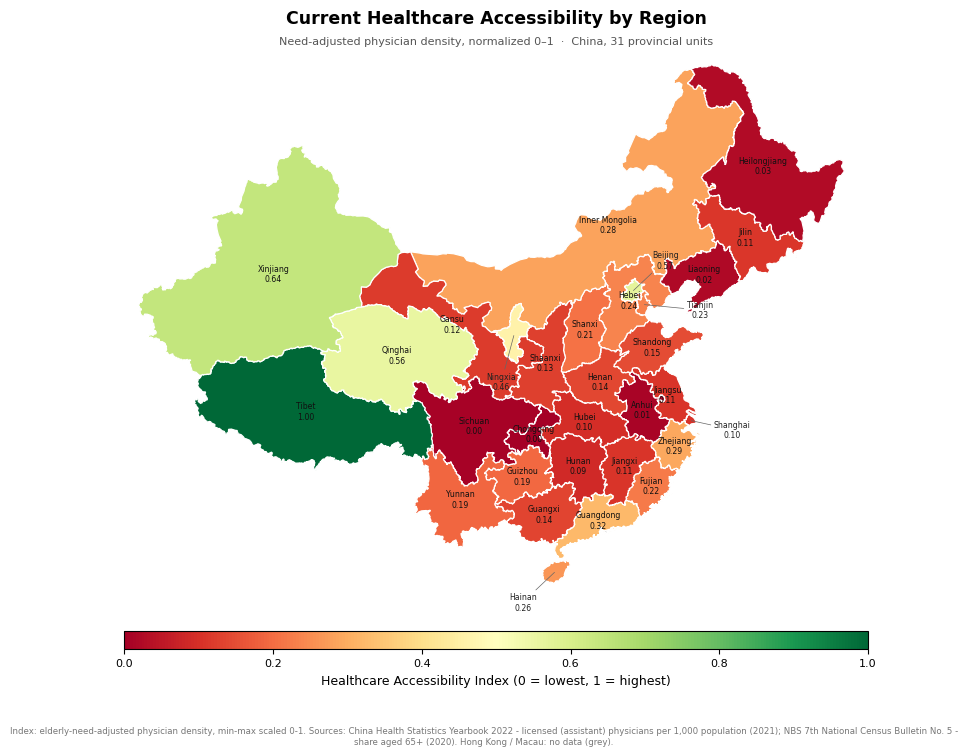

In [7]:
fig, ax = plt.subplots(figsize=(9.6, 8.2))
draw(ax, idx, "Current Healthcare Accessibility by Region",
     "Need-adjusted physician density, normalized 0–1  ·  China, 31 provincial units")
add_cbar(fig, [ax])
fig.text(0.5, 0.005, FOOT, ha="center", fontsize=6.2, color="#777", wrap=True)
fig.savefig("map1_current_accessibility_china.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()

### Map 2 — Projected with platform (30% gap-closure scenario)

/sessions/vigilant-zealous-ritchie/tmp/ipykernel_9/739563186.py:13: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)


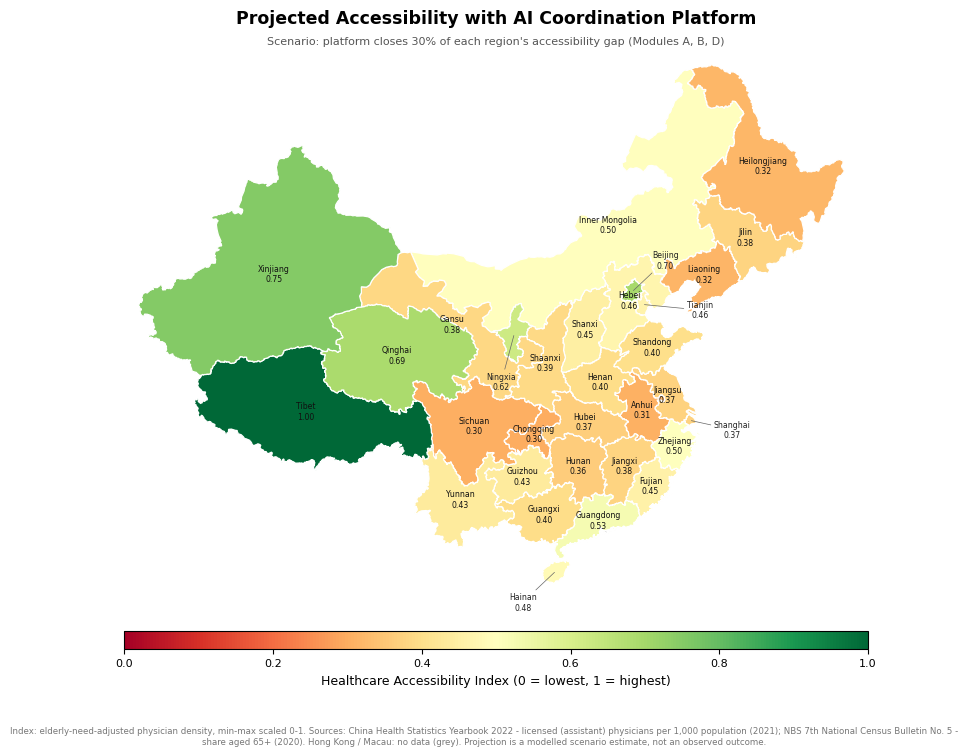

In [8]:
fig, ax = plt.subplots(figsize=(9.6, 8.2))
draw(ax, proj, "Projected Accessibility with AI Coordination Platform",
     "Scenario: platform closes 30% of each region's accessibility gap (Modules A, B, D)")
add_cbar(fig, [ax])
fig.text(0.5, 0.005,
         FOOT + " Projection is a modelled scenario estimate, not an observed outcome.",
         ha="center", fontsize=6.2, color="#777", wrap=True)
fig.savefig("map2_projected_accessibility_china.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()

### Map 3 — Side-by-side comparison

/sessions/vigilant-zealous-ritchie/tmp/ipykernel_9/739563186.py:13: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)


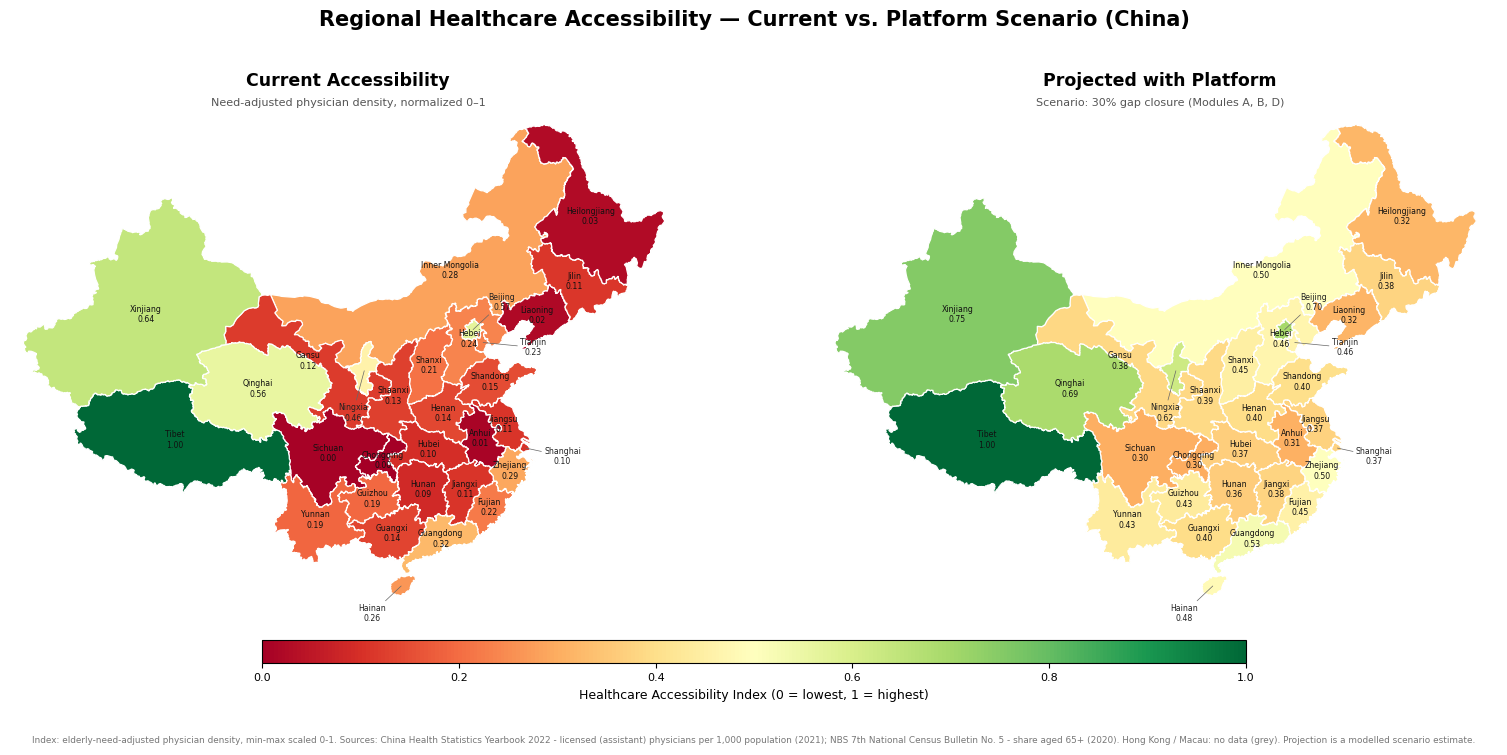

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 7.6))
fig.subplots_adjust(top=0.88, left=0.02, right=0.98)
draw(axes[0], idx,  "Current Accessibility",
     "Need-adjusted physician density, normalized 0–1")
draw(axes[1], proj, "Projected with Platform",
     "Scenario: 30% gap closure (Modules A, B, D)")
add_cbar(fig, axes)
fig.suptitle("Regional Healthcare Accessibility — Current vs. Platform Scenario (China)",
             fontsize=15, fontweight="bold", y=0.97)
fig.text(0.5, 0.005, FOOT + " Projection is a modelled scenario estimate.",
         ha="center", fontsize=6.4, color="#777")
fig.savefig("map3_side_by_side_china.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Step 7 — Verification, sensitivity, export

**Checks:** index bounds are exactly [0, 1]; projected ≥ current everywhere with the
largest gains in the reddest regions; the bottom of the ranking (Chongqing, Sichuan,
Anhui, Liaoning, Heilongjiang — the aged Northeast + Sichuan basin) matches the
independent press cross-check on China's oldest provinces, and the two lowest raw-supply
provinces (Jiangxi, Guangdong) are the text-verified minima.

**Estimate robustness:** because 24 of 31 `doctors_per_1k` values carry `doc_est = True`,
we re-run the pipeline 500 times with every estimated value perturbed by U(−0.2, +0.2)
and report how often the bottom-5 set is preserved.

In [10]:
assert abs(df["index_current"].min()) < 1e-9 and abs(df["index_current"].max() - 1) < 1e-9
assert (df["index_projected"] >= df["index_current"] - 1e-9).all()
assert df.sort_values("gain", ascending=False).iloc[0]["region"] == "Chongqing"

# Sensitivity 1: rerun the scenario at three gap-closure levels
sens = pd.DataFrame({f"gamma={g:.0%}": df["index_current"] + g * (1 - df["index_current"])
                     for g in (0.15, 0.30, 0.45)})
sens.insert(0, "region", df["region"])
sens.insert(1, "current", df["index_current"])
sens.sort_values("current").round(2)

,region,current,gamma=15%,gamma=30%,gamma=45%
key,,,,,
chongqing,Chongqing,0.00,0.15,0.30,0.45
sichuan,Sichuan,0.00,0.15,0.30,0.45
anhui,Anhui,0.01,0.16,0.31,0.46
liaoning,Liaoning,0.02,0.17,0.32,0.46
heilongjiang,Heilongjiang,0.03,0.17,0.32,0.46
hunan,Hunan,0.09,0.22,0.36,0.50
hubei,Hubei,0.10,0.23,0.37,0.50
shanghai,Shanghai,0.10,0.24,0.37,0.51
jiangsu,Jiangsu,0.11,0.24,0.37,0.51


In [11]:
# Sensitivity 2: robustness of the bottom-5 ranking to the estimated doctor values
rng = np.random.default_rng(42)
base_bottom5 = set(df.sort_values("index_current").head(5)["region"])
hits = 0
for _ in range(500):
    d = df["doctors_per_1k"].copy()
    noise = rng.uniform(-0.2, 0.2, size=len(d))
    d[df["doc_est"]] += noise[df["doc_est"].values]
    s = d / df["need_ratio"]
    i = (s - s.min()) / (s.max() - s.min())
    hits += set(df.assign(i=i).sort_values("i").head(5)["region"]) == base_bottom5
print(f"bottom-5 set {sorted(base_bottom5)}")
print(f"preserved in {hits/500:.0%} of 500 perturbed runs (est. values jittered U(-0.2, +0.2))")

bottom-5 set ['Anhui', 'Chongqing', 'Heilongjiang', 'Liaoning', 'Sichuan']
preserved in 100% of 500 perturbed runs (est. values jittered U(-0.2, +0.2))


In [12]:
out = df[["region", "doctors_per_1k", "pct_65plus", "doc_est",
          "need_adj_supply", "index_current", "index_projected"]].round(3)
out.to_csv("accessibility_index_data_china.csv", index=False)
print("saved: accessibility_index_data_china.csv, map1/2/3 PNGs")

saved: accessibility_index_data_china.csv, map1/2/3 PNGs


## References

1. National Bureau of Statistics of China, *Seventh National Population Census Bulletin
   No. 5* (第七次全国人口普查公报（第五号）— 人口年龄构成情况), Table 5-2, May 11 2021.
   https://www.stats.gov.cn/sj/zxfb/202302/t20230203_1901085.html
2. National Health Commission, *China Health Statistics Yearbook 2022* (中国卫生健康统计年鉴),
   table 2-2-2 — licensed (assistant) physicians per 1,000 population by region, 2021.
   Yearbook portal: https://www.nhc.gov.cn/mohwsbwstjxxzx/tjtjnj/
3. 赛柏蓝 (张自然), "各省医疗资源 | 5图排名", via 健康界, Dec 17 2022 — text-verified 2021
   anchors: Beijing 5.1 (max), Tianjin 3.8, Shanghai 3.4, Shandong 3.4, Henan 3.0 (median),
   Jiangxi 2.5 (min), Guangdong 2.5.
   https://www.cn-healthcare.com/articlewm/20221217/content-1484954.html
4. 罗志恒 (粤开证券), "动态清零有必要：基于31省份和36城市的医疗资源分析", 界面新闻, Apr 15 2022 —
   regional ordering cross-check. https://www.jiemian.com/article/7337901.html
5. National Health Commission, *2023 Statistical Bulletin on Health Development*
   (2023年我国卫生健康事业发展统计公报) — national 3.40 physicians / 1,000 (2023).
   https://www.gov.cn/lianbo/bumen/202408/content_6971248.htm
6. 澎湃新闻, "19省份迈过中度老龄化门槛，东北、川渝老龄化严重", Nov 2024 — aging cross-check
   (Liaoning 21.1% oldest). https://m.thepaper.cn/newsDetail_forward_29348480
7. Zhang et al., *Equity analysis of Chinese physician allocation based on Gini
   coefficient and Theil index*, BMC Health Services Research, 2021 (PMC8115393) —
   population-based vs. area-based distribution caveat.
8. Boundary geometry: `@svg-maps/china` v2.0.0 (MIT).
   https://www.npmjs.com/package/@svg-maps/china